In [1]:
# import library
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn import tree


from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import accuracy_score, classification_report

### Stanley Tan Ibrahim 
### Bernardo Frederick Kowe

# Data Understanding

In [2]:
# load dataset
url = "https://raw.githubusercontent.com/BearBranddddd/DataMining_Bernardo-Frederick-Kowe/main/telco_data.csv"
df = pd.read_csv(url)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1.0,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34.0,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2.0,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45.0,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2.0,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            6293 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           6043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            4543 non-null   float64
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   6043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       5543 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
print(df.shape)

(7043, 21)


In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,4543.000000,5543.000000
mean,0.162147,32.546555,64.876403
std,0.368612,24.505519,30.101331
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.750000
50%,0.000000,29.000000,70.550000
75%,0.000000,56.000000,89.925000
max,1.000000,72.000000,118.600000


In [6]:
# Check for NaN values
df.isna().sum()

customerID             0
gender               750
SeniorCitizen          0
Partner             1000
Dependents             0
tenure              2500
PhoneService           0
MultipleLines          0
InternetService     1000
OnlineSecurity         0
OnlineBackup           0
DeviceProtection       0
TechSupport            0
StreamingTV         1500
StreamingMovies        0
Contract               0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges      1500
TotalCharges           0
Churn                  0
dtype: int64

In [7]:
# Melihat Persentase Missing Values
missing_data = df.isnull().sum()
missing_percentage = (missing_data / len(df)) * 100

missing_info = pd.DataFrame({
    'Total Missing': missing_data,
    'Percentage (%)': missing_percentage
}).sort_values(by='Percentage (%)', ascending=False)

# Tampilkan hanya yang ada missing valuenya saja
print(missing_info[missing_info['Total Missing'] > 0])

                 Total Missing  Percentage (%)
tenure                    2500       35.496237
StreamingTV               1500       21.297742
MonthlyCharges            1500       21.297742
InternetService           1000       14.198495
Partner                   1000       14.198495
gender                     750       10.648871


In [8]:
# Cek Duplikat data
print(f"Jumlah baris duplikat: {df.duplicated().sum()}")

Jumlah baris duplikat: 0


In [9]:
# Nilai tiap column

for col in df.columns:
    print(f"=== {col} ===")
    print(df[col].value_counts(dropna=False))
    print("\n")

=== customerID ===
customerID
3186-AJIEK    1
7590-VHVEG    1
5575-GNVDE    1
8775-CEBBJ    1
2823-LKABH    1
             ..
6713-OKOMC    1
1452-KIOVK    1
9305-CDSKC    1
9237-HQITU    1
7795-CFOCW    1
Name: count, Length: 7043, dtype: int64


=== gender ===
gender
Male      3202
Female    3091
NaN        750
Name: count, dtype: int64


=== SeniorCitizen ===
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64


=== Partner ===
Partner
No     3115
Yes    2928
NaN    1000
Name: count, dtype: int64


=== Dependents ===
Dependents
No     4933
Yes    2110
Name: count, dtype: int64


=== tenure ===
tenure
NaN     2500
1.0      379
72.0     240
2.0      140
3.0      133
        ... 
58.0      38
36.0      36
40.0      35
38.0      34
0.0        8
Name: count, Length: 74, dtype: int64


=== PhoneService ===
PhoneService
Yes    6361
No      682
Name: count, dtype: int64


=== MultipleLines ===
MultipleLines
No                  3390
Yes                 2971
No phone service     682
N

In [10]:
print(df.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [11]:
# Cek Non-Numeric pada TotalCharges
# Kita paksa convert ke numeric, yang error (non-numeric) akan jadi NaN karena sebelumnya TotalCharge tidaka da nilai null
total_charges_error = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Nampilin baris yang ternyata isinya bukan angka (NaN setelah dipaksa convert mungkin awalnya string dll)
print("Baris dengan TotalCharges bermasalah (kosong/spasi):")
print(df[total_charges_error.isna()][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']])

# Jumlah yang TotalChargenya jadi null anggep aja string sebelumnya
print(f"\nJumlah baris di TotalCharges yang null: {total_charges_error.isna().sum()}")

Baris dengan TotalCharges bermasalah (kosong/spasi):
      customerID  tenure  MonthlyCharges TotalCharges
488   4472-LVYGI     0.0           52.55             
753   3115-CZMZD     0.0           20.25             
936   5709-LVOEQ     0.0           80.85             
1082  4367-NUYAO     0.0           25.75             
1340  1371-DWPAZ     NaN           56.05             
3331  7644-OMVMY     0.0           19.85             
3826  3213-VVOLG     0.0           25.35             
4380  2520-SGTTA     0.0           20.00             
5218  2923-ARZLG     0.0           19.70             
6670  4075-WKNIU     NaN             NaN             
6754  2775-SEFEE     NaN             NaN             

Jumlah baris di TotalCharges yang null: 11


In [12]:
df[['tenure', 'MonthlyCharges', 'TotalCharges']].head()

,tenure,MonthlyCharges,TotalCharges
0,1.0,29.85,29.85
1,34.0,56.95,1889.5
2,2.0,53.85,108.15
3,45.0,42.30,1840.75
4,2.0,70.70,151.65


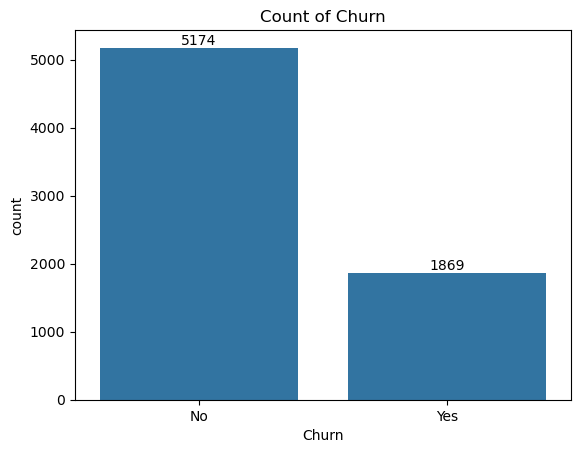

In [13]:
ax = sns.countplot(data=df, x='Churn')
plt.title('Count of Churn')

for container in ax.containers:
    ax.bar_label(container)
plt.show()

Berdasarkan visualisasi distribusi variabel target, terlihat ketidakseimbangan kelas (class imbalance) yang signifikan, di mana proporsi pelanggan yang tidak berhenti (No Churn) mendominasi sebesar 73%, sedangkan pelanggan yang berhenti (Churn) hanya berjumlah 27%. Ketimpangan rasio ini berpotensi menyebabkan model machine learning menjadi bias, di mana model akan cenderung memprediksi kelas mayoritas saja demi mencapai akurasi tinggi secara instan, namun gagal mendeteksi kelas minoritas yang justru menjadi fokus utama prediksi.

## Preprocessing

In [14]:
df_clean = df.copy()

In [15]:
# Fix TotalCharges (Object -> Numeric)
# Mengubah string kosong jadi NaN
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')

In [16]:
df_clean.isna().sum()

customerID             0
gender               750
SeniorCitizen          0
Partner             1000
Dependents             0
tenure              2500
PhoneService           0
MultipleLines          0
InternetService     1000
OnlineSecurity         0
OnlineBackup           0
DeviceProtection       0
TechSupport            0
StreamingTV         1500
StreamingMovies        0
Contract               0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges      1500
TotalCharges          11
Churn                  0
dtype: int64

In [17]:
# ISI TENURE (Rumus: Tenure = Total / Monthly)
# Kondisi: Tenure Kosong, tapi Monthly & Total ADA
cond_tenure = (
    df_clean['tenure'].isna() & 
    df_clean['MonthlyCharges'].notna() & 
    df_clean['TotalCharges'].notna() & 
    (df_clean['MonthlyCharges'] != 0)
)

# Hitung Tenure
df_clean.loc[cond_tenure, 'tenure'] = df_clean.loc[cond_tenure, 'TotalCharges'] / df_clean.loc[cond_tenure, 'MonthlyCharges']

# Kita bulatkan hasil bagi tadi agar jadi bulan utuh (Integer logic)
df_clean.loc[cond_tenure, 'tenure'] = df_clean.loc[cond_tenure, 'tenure'].round()


# ISI MONTHLY CHARGES (Rumus: Monthly = Total / Tenure)
# Kondisi: Monthly Kosong, tapi Tenure & Total ADA
cond_monthly = (
    df_clean['MonthlyCharges'].isna() & 
    df_clean['tenure'].notna() & 
    df_clean['TotalCharges'].notna() & 
    (df_clean['tenure'] != 0)
)
df_clean.loc[cond_monthly, 'MonthlyCharges'] = df_clean.loc[cond_monthly, 'TotalCharges'] / df_clean.loc[cond_monthly, 'tenure']

# Tenure & Monthly sisa -> Diisi MEDIAN
cols_median = ['tenure', 'MonthlyCharges']
for col in cols_median:
    if df_clean[col].isna().sum() > 0:
        median_val = df_clean[col].median()
        # Khusus Tenure, mediannya juga harus bulat biar rapi dan data konsisten
        if col == 'tenure':
            median_val = round(median_val)
        
        df_clean[col] = df_clean[col].fillna(median_val)
        print(f"[Imputasi] Sisa {col} diisi Median: {median_val}")

# Kategorikal -> Diisi MODUS
cols_mode = ['gender', 'Partner', 'InternetService', 'StreamingTV', 'SeniorCitizen'] 
for col in cols_mode:
    if col in df_clean.columns and df_clean[col].isna().sum() > 0:
        mode_val = df_clean[col].mode()[0]
        df_clean[col] = df_clean[col].fillna(mode_val)

# Karena Tenure sudah dibulatkan, kita hitung ulang TotalCharges
# agar datanya konsisten: Total = Tenure (Bulat) x MonthlyCharges

df_clean['TotalCharges'] = df_clean['tenure'] * df_clean['MonthlyCharges']
print("[Success] TotalCharges dihitung ulang berdasarkan Tenure yang sudah dibulatkan.")

df_clean['Churn_Code'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})

print(df_clean[['tenure', 'MonthlyCharges', 'TotalCharges']].head())

[Imputasi] Sisa tenure diisi Median: 29
[Imputasi] Sisa MonthlyCharges diisi Median: 70.55
[Success] TotalCharges dihitung ulang berdasarkan Tenure yang sudah dibulatkan.
   tenure  MonthlyCharges  TotalCharges
0     1.0           29.85         29.85
1    34.0           56.95       1936.30
2     2.0           53.85        107.70
3    45.0           42.30       1903.50
4     2.0           70.70        141.40


In [18]:
df_clean.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
Churn_Code          0
dtype: int64

# EDA

### Analisis Fitur Numerik (Distribusi & Outlier)

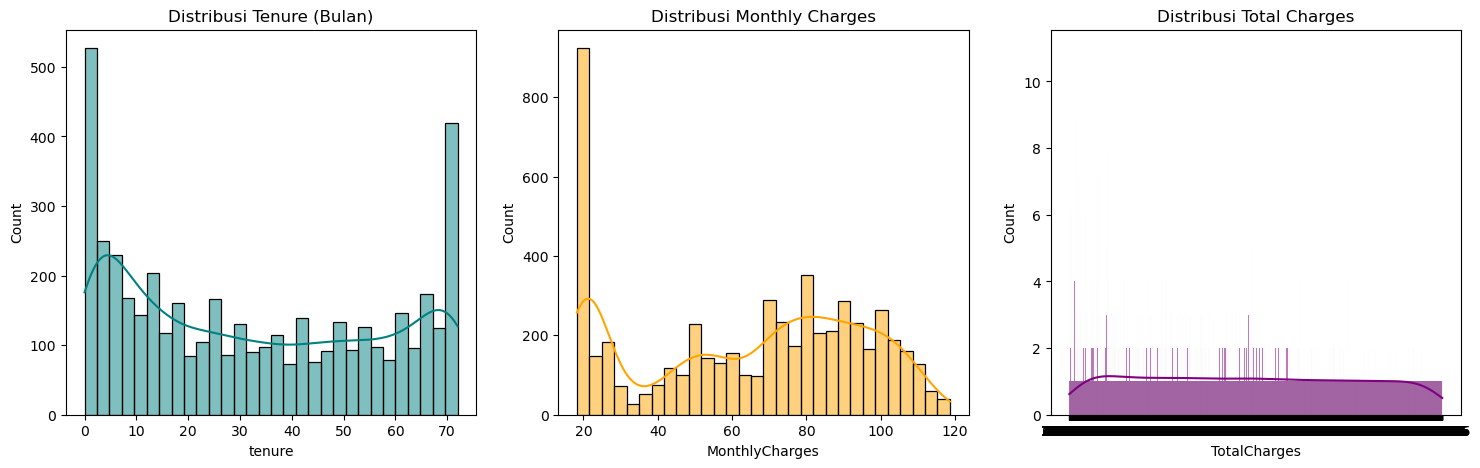

In [19]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['tenure'], bins=30, kde=True, color='teal', ax=ax[0])
ax[0].set_title('Distribusi Tenure (Bulan)')

sns.histplot(df['MonthlyCharges'], bins=30, kde=True, color='orange', ax=ax[1])
ax[1].set_title('Distribusi Monthly Charges')

sns.histplot(df['TotalCharges'], bins=30, kde=True, color='purple', ax=ax[2])
ax[2].set_title('Distribusi Total Charges')

plt.show()

Berdasarkan hasil eksplorasi data pada fitur numerik, ditemukan pola distribusi yang memberikan wawasan penting mengenai karakteristik pelanggan. Pada variabel Tenure (masa berlangganan), terlihat adanya polarisasi yang ekstrem membentuk pola "U-shape", di mana konsentrasi pelanggan terbesar berkumpul di dua ujung spektrum: pelanggan yang sangat baru (0–5 bulan) dan pelanggan yang sangat loyal (di atas 70 bulan). Hal ini mengindikasikan bahwa risiko churn tertinggi kemungkinan besar terjadi pada fase awal masa berlangganan, sementara pelanggan yang berhasil melewati periode kritis tersebut cenderung akan bertahan dalam jangka panjang.

Sejalan dengan itu, distribusi Monthly Charges menunjukkan bahwa mayoritas basis pelanggan lebih memilih layanan dasar dengan biaya rendah (kisaran $20), meskipun terdapat segmen sekunder yang cukup signifikan di kisaran harga $70–$100 yang merepresentasikan pengguna layanan premium/fiber optic. Dominasi pelanggan baru dan pengguna paket dasar ini secara langsung mempengaruhi distribusi Total Charges yang menjulur ke kanan (positively skewed), menandakan bahwa sebagian besar pelanggan dalam dataset belum memiliki akumulasi pembayaran total yang tinggi.

### Analisis Hubungan Numerik vs Churn

C:\Users\Bernard\AppData\Local\Temp\ipykernel_31380\2290970365.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df, palette='Set2', ax=ax[0])
C:\Users\Bernard\AppData\Local\Temp\ipykernel_31380\2290970365.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='Set2', ax=ax[1])
C:\Users\Bernard\AppData\Local\Temp\ipykernel_31380\2290970365.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='TotalCharges', data=df, palette='Set2', ax=ax[2])


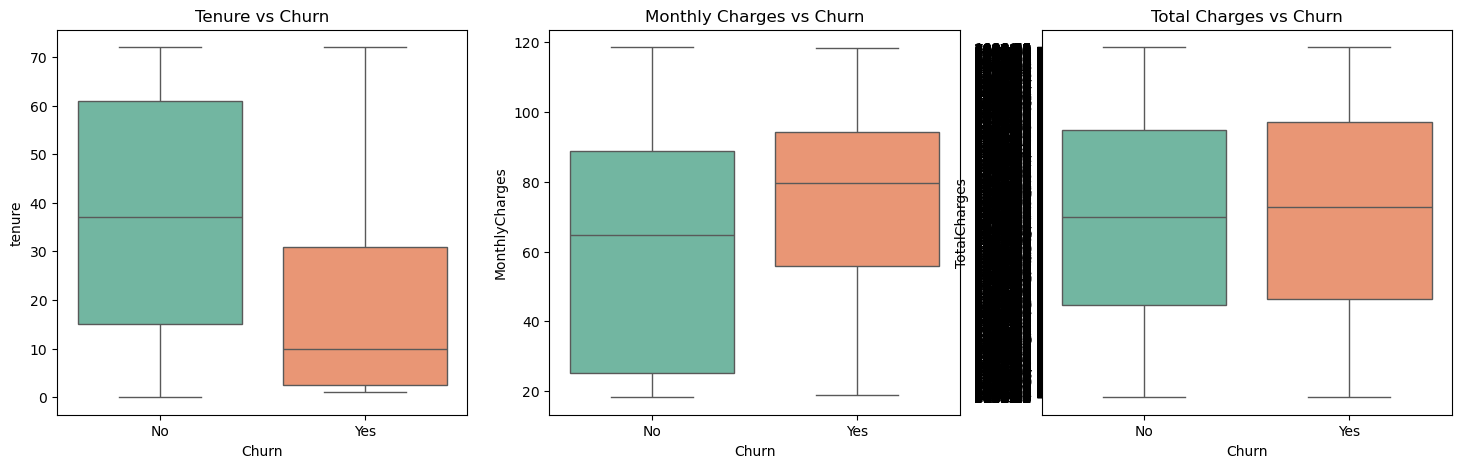

In [20]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(x='Churn', y='tenure', data=df, palette='Set2', ax=ax[0])
ax[0].set_title('Tenure vs Churn')

sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='Set2', ax=ax[1])
ax[1].set_title('Monthly Charges vs Churn')

sns.boxplot(x='Churn', y='TotalCharges', data=df, palette='Set2', ax=ax[2])
ax[2].set_title('Total Charges vs Churn')

plt.show()

Analisis hubungan antara variabel numerik dan status Churn melalui visualisasi boxplot memperlihatkan perbedaan karakteristik yang signifikan antara pelanggan setia dan pelanggan yang berhenti. Pada grafik Tenure vs Churn, terlihat jelas bahwa pelanggan yang melakukan churn didominasi oleh mereka yang memiliki masa berlangganan sangat singkat, dengan median tenure hanya berkisar di angka 10 bulan. Sebaliknya, pelanggan yang bertahan (No Churn) memiliki sebaran masa berlangganan yang jauh lebih luas dan tinggi, mengonfirmasi bahwa loyalitas pelanggan terbangun seiring berjalannya waktu dan risiko kehilangan pelanggan paling besar terjadi di tahun pertama.

Pola yang berbeda ditemukan pada aspek pembiayaan. Grafik Monthly Charges vs Churn menunjukkan bahwa pelanggan yang memutuskan untuk berhenti cenderung memiliki beban tagihan bulanan yang lebih tinggi (median sekitar $80) dibandingkan pelanggan yang tetap berlangganan. Hal ini mengindikasikan adanya sensitivitas harga, di mana pelanggan dengan paket layanan mahal lebih rentan untuk berpindah. Sementara itu, pada Total Charges, meskipun tagihan bulanan kelompok churn tinggi, total akumulasi pembayaran mereka cenderung lebih rendah atau setara dengan pelanggan setia; fenomena ini terjadi karena masa berlangganan (tenure) mereka yang pendek sehingga belum sempat mengakumulasi total pembayaran yang besar.

### Analisis Fitur Kategorikal vs Churn

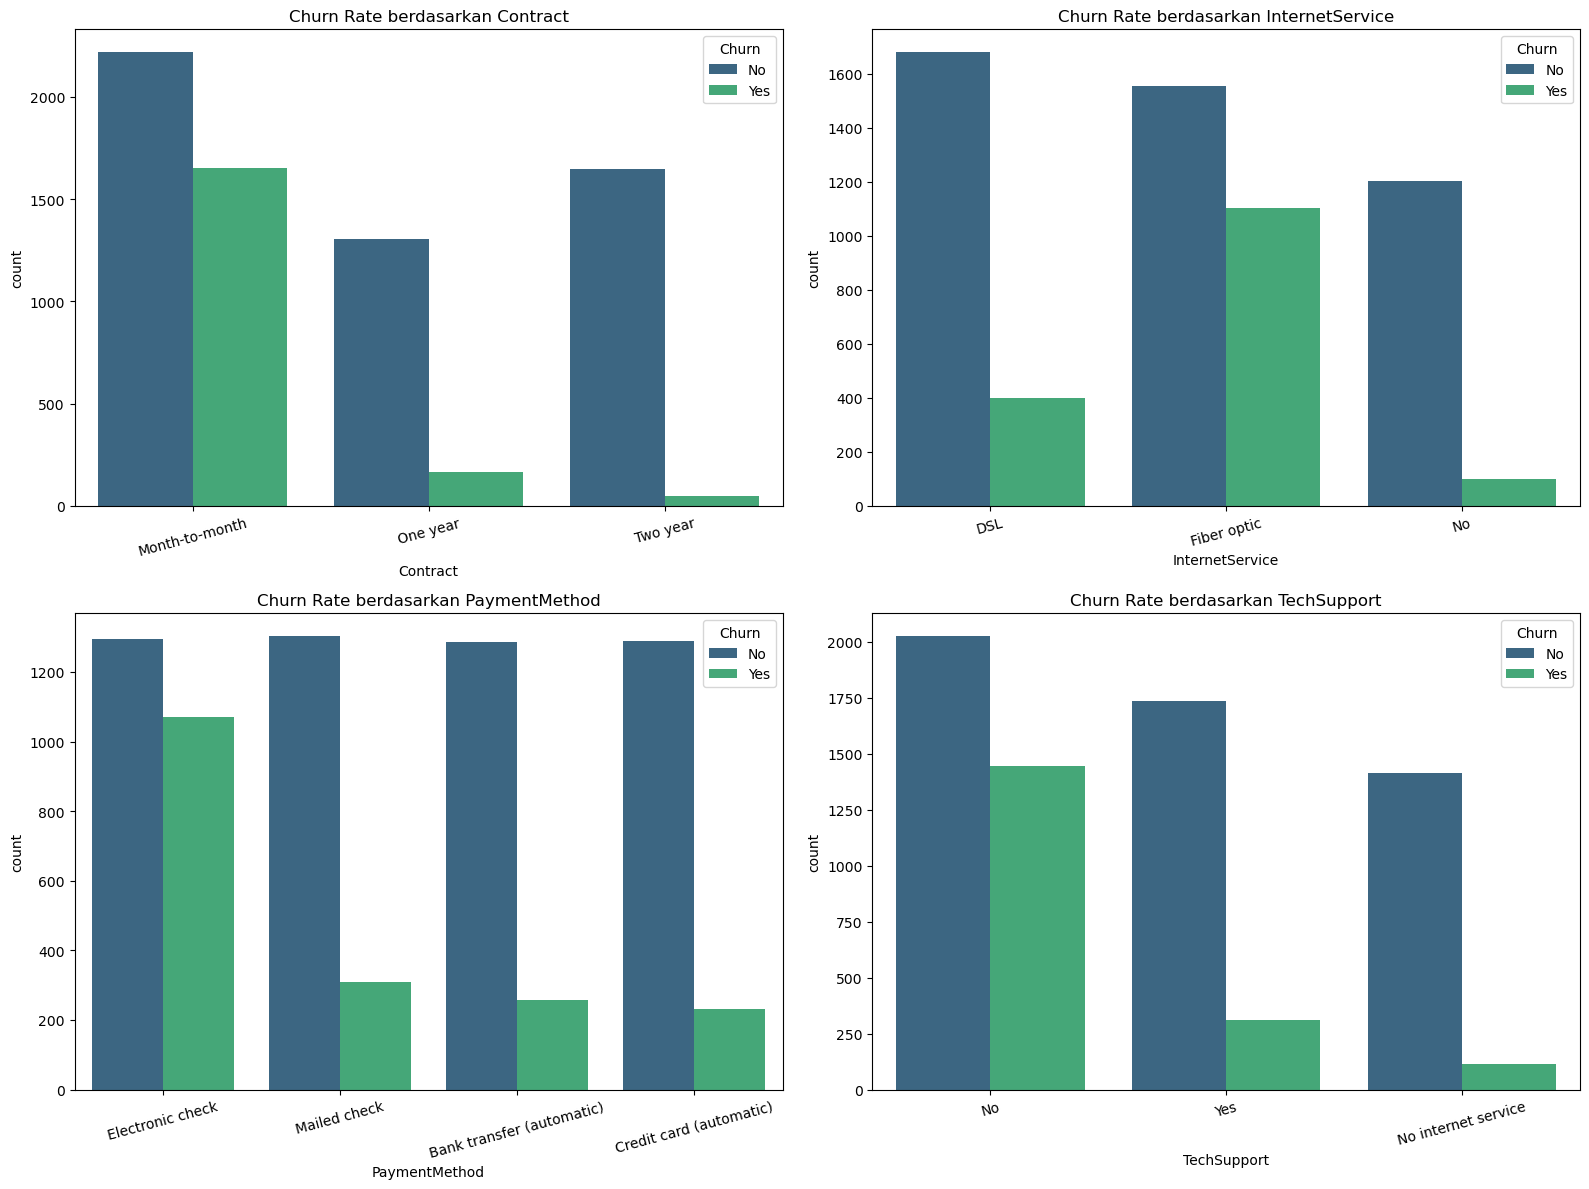

In [21]:
cols_to_check = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for i, col in enumerate(cols_to_check):
    sns.countplot(x=col, hue='Churn', data=df, ax=axes[i//2, i%2], palette='viridis')
    axes[i//2, i%2].set_title(f'Churn Rate berdasarkan {col}')
    axes[i//2, i%2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

Analisis mendalam terhadap fitur kategorikal mengungkapkan beberapa faktor kunci yang menjadi pemicu utama keputusan pelanggan untuk berhenti berlangganan. Berdasarkan variabel Contract, ditemukan disparitas yang sangat tajam di mana pelanggan dengan kontrak bulanan (Month-to-month) memiliki tingkat churn yang sangat masif dibandingkan pelanggan dengan kontrak jangka panjang (satu atau dua tahun), hal ini mengonfirmasi bahwa ketiadaan komitmen jangka panjang memudahkan pelanggan untuk berpindah ke kompetitor. Pola menarik lainnya terlihat pada jenis layanan internet (InternetService), di mana pengguna Fiber Optic justru menunjukkan rasio churn yang jauh lebih tinggi dibandingkan pengguna DSL, yang mungkin mengindikasikan adanya isu ketidakpuasan terhadap kualitas atau harga pada segmen tersebut. Selain itu, metode pembayaran (PaymentMethod) turut memberikan sinyal peringatan, di mana pelanggan yang menggunakan Electronic Check memiliki kecenderungan churn paling tinggi dibandingkan metode pembayaran otomatis lainnya. Terakhir, variabel TechSupport memperlihatkan peran vital layanan purna jual, di mana pelanggan yang tidak mengambil opsi dukungan teknis memiliki risiko churn yang jauh lebih besar dibandingkan mereka yang memanfaatkan layanan tersebut.

### Correlation Heatmap

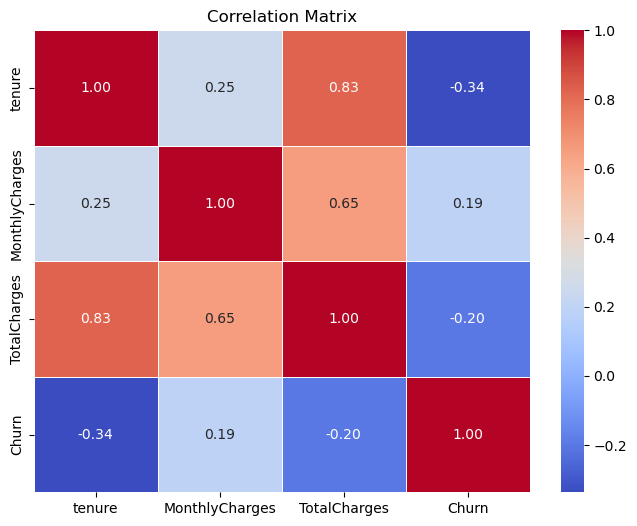

In [22]:
df_heat = df.copy()
df_heat['TotalCharges'] = pd.to_numeric(df_heat['TotalCharges'], errors='coerce')
df_heat['TotalCharges'] = df_heat['TotalCharges'].fillna(0)

if df_heat['Churn'].dtype == 'O': 
    df_heat['Churn'] = df_heat['Churn'].map({'Yes': 1, 'No': 0})
    
numeric_df = df_heat[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]

plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

Analisis matriks korelasi mengungkapkan hubungan antar variabel numerik, di mana temuan paling signifikan adalah adanya korelasi positif yang sangat kuat (0.83) antara Tenure dan TotalCharges. Hal ini mengindikasikan adanya multikolinearitas, yang wajar terjadi karena total tagihan merupakan fungsi akumulasi dari lama berlangganan; implikasinya, kedua fitur ini membawa informasi yang redundan. Ditinjau dari hubungannya dengan variabel target (Churn), Tenure memiliki korelasi negatif moderat (-0.34), yang mengonfirmasi bahwa semakin lama masa berlangganan seseorang, semakin kecil kecenderungan mereka untuk berhenti (churn). Sebaliknya, MonthlyCharges menunjukkan korelasi positif lemah (0.19), yang mengisyaratkan bahwa semakin tinggi beban tagihan bulanan, semakin besar pula potensi pelanggan untuk beralih. Menariknya, meskipun MonthlyCharges berkorelasi positif dengan Churn, TotalCharges justru berkorelasi negatif (-0.20); anomali ini terjadi karena TotalCharges sangat dipengaruhi oleh Tenure (pelanggan dengan Total Charges tinggi biasanya adalah pelanggan lama yang setia), sehingga efek loyalitas dari Tenure lebih mendominasi daripada efek harga.

## Feature Engineering

In [23]:
df_model = df_clean.copy()

In [24]:
df_model.drop(columns=['customerID', 'Churn'], inplace=True)

In [25]:
df_model['Contract'] = df_model['Contract'].map({
    'Month-to-month': 0,
    'One year': 1,
    'Two year': 2
})

df_model['gender'] = df_model['gender'].map({'Male': 1, 'Female': 0})

# Yes/No
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    df_model[col] = df_model[col].map({'Yes': 1, 'No': 0})

In [ ]:
# Strategi: Jika 'Yes' -> 1. Sisanya ('No' atau 'No... service') -> 0.
# "Konsistensi Binary".

service_cols = [
    'MultipleLines',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

for col in service_cols:
    # Logic: Kalau isinya 'Yes' jadi 1, selain itu (No/No service) jadi 0
    df_model[col] = np.where(df_model[col] == 'Yes', 1, 0)

# ONE-HOT ENCODING (NOMINAL)
# Sisanya tinggal PaymentMethod dan InternetService
nominal_cols = ['InternetService', 'PaymentMethod']
df_model = pd.get_dummies(df_model, columns=nominal_cols, drop_first=True)

print(df_model.columns.tolist())

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn_Code', 'InternetService_Fiber optic', 'InternetService_No', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [27]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   float64
 5   PhoneService                           7043 non-null   int64  
 6   MultipleLines                          7043 non-null   int64  
 7   OnlineSecurity                         7043 non-null   int64  
 8   OnlineBackup                           7043 non-null   int64  
 9   DeviceProtection                       7043 non-null   int64  
 10  TechSupport                            7043 non-null   int64  
 11  Stre

## Separate features and target

In [28]:
X = df_model.drop('Churn_Code', axis=1)
y = df_model['Churn_Code']

In [29]:
X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,StreamingMovies,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1.0,0,0,0,1,0,...,0,0,1,29.85,29.85,False,False,False,True,False
1,1,0,0,0,34.0,1,0,1,0,1,...,0,1,0,56.95,1936.30,False,False,False,False,True
2,1,0,0,0,2.0,1,0,1,1,0,...,0,0,1,53.85,107.70,False,False,False,False,True
3,1,0,0,0,45.0,0,0,1,0,1,...,0,1,0,42.30,1903.50,False,False,False,False,False
4,0,0,0,0,2.0,1,0,0,0,0,...,0,0,1,70.70,141.40,True,False,False,True,False


In [30]:
y.head()

0    0
1    0
2    1
3    0
4    1
Name: Churn_Code, dtype: int64

## Split data

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [32]:
# check the shape of X_train and X_test

X_train.shape, X_test.shape

((5634, 22), (1409, 22))

In [33]:
X_train.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,StreamingMovies,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
2142,0,0,0,1,29.0,1,0,1,0,1,...,1,1,0,70.55,2045.95,False,False,False,False,True
1623,0,0,0,0,29.0,1,1,0,1,0,...,1,2,1,70.55,2045.95,True,False,False,False,False
6074,1,0,1,0,29.0,0,0,0,0,0,...,0,0,1,70.55,2045.95,False,False,False,True,False
1362,1,0,0,0,29.0,1,0,0,0,0,...,0,0,1,70.55,2045.95,True,False,False,True,False
6754,1,0,0,1,29.0,1,1,1,1,0,...,0,2,1,70.55,2045.95,False,False,False,False,False


In [34]:
X_test.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,StreamingMovies,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
185,1,0,0,0,29.0,0,0,0,0,0,...,0,0,1,70.55,2045.95,True,False,False,True,False
2715,1,0,0,0,29.0,1,1,0,0,0,...,0,0,1,70.55,2045.95,True,False,False,False,False
3825,1,0,0,1,29.0,1,0,0,0,0,...,0,2,0,70.55,2045.95,True,False,False,False,True
1807,1,0,0,0,29.0,1,0,0,0,1,...,0,0,0,70.55,2045.95,True,False,False,True,False
132,1,0,0,0,29.0,1,0,0,0,0,...,0,2,0,70.55,2045.95,True,False,False,False,False


# Decision Tree Classifier Without Hyperparameter

In [35]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report

tree = DecisionTreeClassifier(random_state=0)
tree.fit(X_train, y_train)

y_pred_train = tree.predict(X_train)
y_pred_test = tree.predict(X_test)

print("\n=== Classification Report (Training Set) ===")
print(classification_report(y_train, y_pred_train))

print("\n=== Classification Report (Test Set) ===")
print(classification_report(y_test, y_pred_test))


=== Classification Report (Training Set) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4138
           1       1.00      0.99      1.00      1496

    accuracy                           1.00      5634
   macro avg       1.00      1.00      1.00      5634
weighted avg       1.00      1.00      1.00      5634


=== Classification Report (Test Set) ===
              precision    recall  f1-score   support

           0       0.78      0.86      0.81      1036
           1       0.44      0.31      0.36       373

    accuracy                           0.71      1409
   macro avg       0.61      0.58      0.59      1409
weighted avg       0.69      0.71      0.69      1409



# Random Forest Classifier Without Hyperparameter

In [36]:
# Inisialisasi model Random Forest
forest = RandomForestClassifier(random_state=0)

# Latih model dengan data training
forest.fit(X_train, y_train)

# Prediksi pada data training dan test
y_pred_train = forest.predict(X_train)
y_pred_test = forest.predict(X_test)

# Tampilkan hasil evaluasi
print("\n=== Classification Report (Training Set) ===")
print(classification_report(y_train, y_pred_train))

print("\n=== Classification Report (Test Set) ===")
print(classification_report(y_test, y_pred_test))


=== Classification Report (Training Set) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4138
           1       1.00      1.00      1.00      1496

    accuracy                           1.00      5634
   macro avg       1.00      1.00      1.00      5634
weighted avg       1.00      1.00      1.00      5634


=== Classification Report (Test Set) ===
              precision    recall  f1-score   support

           0       0.82      0.89      0.86      1036
           1       0.61      0.47      0.53       373

    accuracy                           0.78      1409
   macro avg       0.71      0.68      0.69      1409
weighted avg       0.77      0.78      0.77      1409



**Analisis Model Awal (Sebelum SMOTE)**

Berdasarkan hasil pemodelan awal (Baseline), terlihat indikasi Overfitting yang sangat kuat pada kedua algoritma (Decision Tree dan Random Forest). Hal ini ditandai dengan skor Training yang sempurna (1.00) namun performa Testing yang menurun cukup jauh (0.71 untuk Decision Tree dan 0.78 untuk Random Forest). Masalah yang paling krusial dan fatal secara bisnis terletak pada ketidakmampuan model dalam mendeteksi pelanggan yang Churn (Kelas 1).

Nilai Recall untuk kelas 1 sangat rendah, yaitu hanya 0.31 pada Decision Tree dan 0.47 pada Random Forest. Artinya, model Decision Tree gagal mendeteksi hampir 70% pelanggan yang sebenarnya ingin berhenti berlangganan, sedangkan Random Forest gagal mendeteksi sekitar 53%. Tingginya akurasi global pada tahap ini adalah "akurasi semu" karena model bias terhadap kelas mayoritas (pelanggan setia/Kelas 0) dan mengabaikan kelas minoritas yang justru menjadi target utama analisis kita.

Selanjutnya kita akan melakukan SMOTE. Rendahnya nilai Recall tersebut disebabkan oleh masalah Imbalanced Data (ketimpangan jumlah data). Model menjadi "malas" dan cenderung menebak semua orang sebagai pelanggan setia karena peluang benarnya lebih besar secara statistik. Oleh karena itu, kita wajib menggunakan teknik SMOTE (Synthetic Minority Over-sampling Technique) pada data latih. Tujuannya adalah menyeimbangkan proporsi kelas target (0 dan 1) agar model dipaksa untuk belajar mengenali pola/ciri-ciri pelanggan Churn dengan lebih serius, bukan sekadar menebak mayoritas demi keamanan skor.

# Oversampling using SMOTE

In [37]:
from imblearn.over_sampling import SMOTE
from collections import Counter

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# sebelum SMOTE
print(f"Data Train Sebelum SMOTE: {Counter(y_train)}")

# SMOTE hanya dilakukan ke X_train dan y_train
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# setelah SMOTE
print(f"Data Train Setelah SMOTE: {Counter(y_train_smote)}")

Data Train Sebelum SMOTE: Counter({0: 4138, 1: 1496})
Data Train Setelah SMOTE: Counter({0: 4138, 1: 4138})


c:\Users\Bernard\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Bernard\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\Bernard\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Bernard\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^

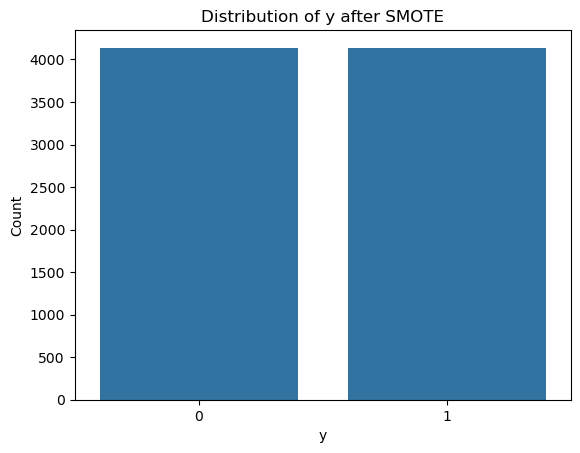

In [38]:
# Visualisasi hasil SMOTE

sns.countplot(x=y_train_smote)
plt.title('Distribution of y after SMOTE')
plt.xlabel('y')
plt.ylabel('Count')
plt.show()

# Decision Tree Classifier Without Hyperparameter After SMOTE

In [39]:
tree = DecisionTreeClassifier(random_state=0)
tree.fit(X_train_smote, y_train_smote)

y_pred_train = tree.predict(X_train_smote)
y_pred_test = tree.predict(X_test)

print("\n=== Classification Report (Training Set) ===")
print(classification_report(y_train_smote, y_pred_train))

print("\n=== Classification Report (Test Set) ===")
print(classification_report(y_test, y_pred_test))


=== Classification Report (Training Set) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4138
           1       1.00      1.00      1.00      4138

    accuracy                           1.00      8276
   macro avg       1.00      1.00      1.00      8276
weighted avg       1.00      1.00      1.00      8276


=== Classification Report (Test Set) ===
              precision    recall  f1-score   support

           0       0.84      0.67      0.74      1036
           1       0.41      0.65      0.50       373

    accuracy                           0.66      1409
   macro avg       0.63      0.66      0.62      1409
weighted avg       0.73      0.66      0.68      1409



# Random Forest Classifier Without Hyperparameter After SMOTE

In [40]:
forest = RandomForestClassifier(random_state=0)

forest.fit(X_train_smote, y_train_smote)

y_pred_train = forest.predict(X_train_smote)
y_pred_test = forest.predict(X_test)

print("\n=== Classification Report (Training Set) ===")
print(classification_report(y_train_smote, y_pred_train))

print("\n=== Classification Report (Test Set) ===")
print(classification_report(y_test, y_pred_test))


=== Classification Report (Training Set) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4138
           1       1.00      1.00      1.00      4138

    accuracy                           1.00      8276
   macro avg       1.00      1.00      1.00      8276
weighted avg       1.00      1.00      1.00      8276


=== Classification Report (Test Set) ===
              precision    recall  f1-score   support

           0       0.83      0.82      0.82      1036
           1       0.52      0.54      0.53       373

    accuracy                           0.74      1409
   macro avg       0.67      0.68      0.68      1409
weighted avg       0.75      0.74      0.75      1409



**Analisis Model Akhir (Setelah SMOTE)**

Setelah penerapan SMOTE, terjadi perubahan performa yang sangat wajar dalam prinsip Machine Learning yang disebut Precision-Recall Trade-off. Secara umum, Akurasi Global memang mengalami penurunan (Decision Tree turun drastis ke 0.66, Random Forest turun sedikit ke 0.74), namun model kini menjadi jauh lebih peka terhadap pelanggan yang berpotensi kabur.

- Decision Tree: Berhasil mencatat Recall tertinggi (0.65), yang berarti mampu menangkap 65% pelanggan churn. Namun, model ini menjadi tidak stabil karena Precision-nya anjlok ke 0.41. Artinya, Decision Tree terlalu agresif dan "panik", sehingga banyak pelanggan setia yang salah dituduh akan churn (False Positive tinggi). Ini terlihat dari F1-Score yang hanya 0.50.

- Random Forest: Menunjukkan performa yang lebih seimbang dan matang. Recall naik menjadi 0.54 (lebih baik dari baseline), dengan Precision yang masih terjaga di angka 0.52. Keseimbangan ini menghasilkan F1-Score tertinggi yaitu 0.53. Model ini mampu mendeteksi churn lebih baik daripada model awal, namun tetap menjaga agar tidak terlalu banyak melakukan kesalahan tebak dibandingkan Decision Tree.

Kesimpulan Pemilihan Model: Berdasarkan analisis di atas, Random Forest Classifier dengan SMOTE dipilih sebagai model terbaik. Meskipun Decision Tree memiliki sensitivitas (Recall) tertinggi, model tersebut terlalu tidak akurat dalam memprediksi (banyak False Alarm). Random Forest menawarkan keseimbangan optimal: F1-Score tertinggi (0.53) dan Akurasi yang andal (74%), menjadikannya solusi paling aman untuk diterapkan secara bisnis.

# Feature Importance

In [41]:
# Ambil importance dari 'forest' yang baru saja dilatih
importances = forest.feature_importances_
feature_names = X_train_smote.columns # Pakai nama kolom dari data train

# Buat DataFrame
df_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
df_imp = df_imp.sort_values(by='Importance', ascending=False)

# Tampilkan
print(df_imp.head(10))

                           Feature  Importance
16                    TotalCharges    0.143113
15                  MonthlyCharges    0.141923
4                           tenure    0.126304
13                        Contract    0.117409
20  PaymentMethod_Electronic check    0.085019
17     InternetService_Fiber optic    0.048873
10                     TechSupport    0.037878
7                   OnlineSecurity    0.037771
3                       Dependents    0.033182
2                          Partner    0.027793


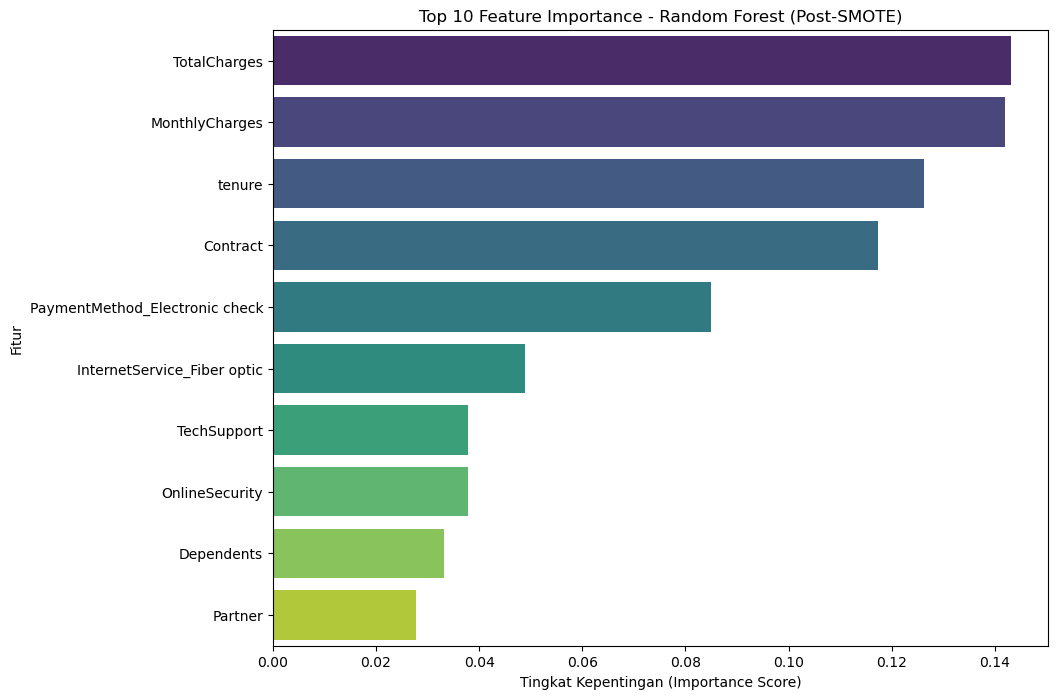

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=df_imp.head(10), 
    palette='viridis', 
    hue='Feature', 
    legend=False
)

plt.title('Top 10 Feature Importance - Random Forest (Post-SMOTE)')
plt.xlabel('Tingkat Kepentingan (Importance Score)')
plt.ylabel('Fitur')
plt.show()

In [43]:
# Kita ambil nama kolom dari dataframe importance yang sudah diurutkan tadi
top_features = df_imp['Feature'].head(10).tolist()

In [44]:
X_train_selected = X_train_smote[top_features]
X_test_selected = X_test[top_features]

# Decision Tree Classifier Without Hyperparameter After Feature Importance

In [45]:
tree_sel = DecisionTreeClassifier(random_state=0)
tree_sel.fit(X_train_selected, y_train_smote)

y_pred_train_tree = tree_sel.predict(X_train_selected)
y_pred_test_tree = tree_sel.predict(X_test_selected)

print("\n=== Classification Report (Training Set) ===")
print(classification_report(y_train_smote, y_pred_train_tree))

print("\n=== Classification Report (Test Set) ===")
print(classification_report(y_test, y_pred_test_tree))


=== Classification Report (Training Set) ===
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      4138
           1       1.00      0.99      0.99      4138

    accuracy                           0.99      8276
   macro avg       0.99      0.99      0.99      8276
weighted avg       0.99      0.99      0.99      8276


=== Classification Report (Test Set) ===
              precision    recall  f1-score   support

           0       0.87      0.66      0.75      1036
           1       0.43      0.72      0.54       373

    accuracy                           0.68      1409
   macro avg       0.65      0.69      0.65      1409
weighted avg       0.75      0.68      0.69      1409



# Random Forest Classifier Without Hyperparameter After Feature Importance

In [46]:
forest_sel = RandomForestClassifier(random_state=0)
forest_sel.fit(X_train_selected, y_train_smote)

y_pred_train_forest = forest_sel.predict(X_train_selected)
y_pred_test_forest = forest_sel.predict(X_test_selected)

print("\n=== Classification Report (Training Set) ===")
print(classification_report(y_train_smote, y_pred_train_forest))

print("\n=== Classification Report (Test Set) ===")
print(classification_report(y_test, y_pred_test_forest))


=== Classification Report (Training Set) ===
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      4138
           1       0.99      1.00      0.99      4138

    accuracy                           0.99      8276
   macro avg       0.99      0.99      0.99      8276
weighted avg       0.99      0.99      0.99      8276


=== Classification Report (Test Set) ===
              precision    recall  f1-score   support

           0       0.87      0.65      0.75      1036
           1       0.43      0.73      0.54       373

    accuracy                           0.67      1409
   macro avg       0.65      0.69      0.65      1409
weighted avg       0.76      0.67      0.69      1409



**Interpretasi Hasil Model dengan Fitur yang penting**

Berdasarkan hasil pengujian menggunakan 10 fitur teratas (Feature Importance), terjadi pergeseran performa yang sangat signifikan dibandingkan dengan model yang menggunakan seluruh fitur.

1. Lonjakan Sensitivitas (Recall): Baik Decision Tree maupun Random Forest menjadi jauh lebih agresif dalam mendeteksi Churn. Nilai Recall untuk kelas Churn meningkat tajam hingga 0.72 - 0.73. Artinya, model mampu menangkap sekitar 73% pelanggan yang berpotensi pergi.

2. Penurunan Akurasi & Presisi: Peningkatan Recall ini harus dibayar dengan penurunan Akurasi Global yang merosot ke angka 67-68% (turun dari ~74%). Hal ini disebabkan oleh rendahnya Precision (0.43), yang mengindikasikan tingginya angka False Positive (banyak pelanggan setia yang salah diprediksi akan churn).

3. Masalah Overfitting Menetap: Meskipun jumlah fitur telah dikurangi, skor Training tetap berada di angka 99%. Hal ini membuktikan bahwa pengurangan fitur saja tidak cukup untuk mengatasi overfitting; model masih memerlukan pembatasan kompleksitas pohon (pruning) melalui pengaturan parameter.

Selanjutnya kita akan melakukan Hyperparameter Tuning, tapi data mana yang akan digunakan??? Kita akan melakukan Hyperparameter Tuning menggunakan data Setelah SMOTE (All Features), bukan data hasil seleksi fitur (Top 10). Alasannya adalah karena

1. Bukti Empiris Penurunan Kualitas: Eksperimen di atas membuktikan bahwa membuang fitur-fitur minor (fitur di luar Top 10) menyebabkan hilangnya informasi kontekstual yang penting. Penurunan akurasi dari 74% (All Features) menjadi 67% (Selected Features) adalah penurunan yang terlalu besar untuk diabaikan. Fitur-fitur kecil tersebut ternyata membantu model menjaga keseimbangan (Precision) agar tidak sembarangan menebak.

2. Tujuan Tuning adalah Efisiensi, Bukan Reduksi: Tujuan Hyperparameter Tuning adalah mencari "settingan otak" model yang paling pas (misalnya: membatasi kedalaman pohon). Algoritma Random Forest secara alami sudah memiliki mekanisme seleksi fitur internal. Dengan memberikan Semua Fitur + Tuning yang Tepat, kita memberikan kesempatan terbaik bagi model untuk mendapatkan akurasi tinggi (dari data lengkap) sekaligus menghilangkan overfitting (dari parameter yang diatur).

3. Fungsi Ganda Feature Importance: Tahap Feature Importance yang dilakukan sebelumnya tetap VALID dan PENTING, tetapi fungsinya berubah:

    - Bukan sebagai Filter Data: Karena terbukti menurunkan akurasi.
    - Melainkan sebagai Wawasan Bisnis: Untuk menjelaskan kepada manajemen faktor apa yang harus diperbaiki dan yang paling berpengaruh terhadap Churn (Harga, Kontrak, dll).

# Hyperparameter Tuning using Grid Search

# Decision Tree Classifier

In [47]:
# Parameter grid
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Inisialisasi Model
tree = DecisionTreeClassifier(random_state=42)

# GridSearch (CV=5)
grid_search_dt = GridSearchCV(
    estimator=tree,
    param_grid=param_grid_dt,
    scoring='f1',
    cv=5,      
    n_jobs=-1,
    verbose=1
)

print("=== Mulai Tuning Decision Tree (CV=5) ===")
# Fit ke DATA SMOTE
grid_search_dt.fit(X_train_smote, y_train_smote)

# Ambil Model Terbaik
best_tree = grid_search_dt.best_estimator_

# Prediksi (Training & Test)
y_pred_train_dt = best_tree.predict(X_train_smote) 
y_pred_test_dt = best_tree.predict(X_test)         

# Output Evaluasi Decision Tree
print(f"Best parameters (DT): {grid_search_dt.best_params_}")
print(f"Best CV F1 score: {grid_search_dt.best_score_:.2f}")

print("\n--- Decision Tree: Classification Report (Training Set) ---")
print(classification_report(y_train_smote, y_pred_train_dt))

print("\n--- Decision Tree: Classification Report (Test Set) ---")
print(classification_report(y_test, y_pred_test_dt))

=== Mulai Tuning Decision Tree (CV=5) ===
Fitting 5 folds for each of 90 candidates, totalling 450 fits
Best parameters (DT): {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best CV F1 score: 0.81

--- Decision Tree: Classification Report (Training Set) ---
              precision    recall  f1-score   support

           0       0.89      0.85      0.87      4138
           1       0.85      0.90      0.87      4138

    accuracy                           0.87      8276
   macro avg       0.87      0.87      0.87      8276
weighted avg       0.87      0.87      0.87      8276


--- Decision Tree: Classification Report (Test Set) ---
              precision    recall  f1-score   support

           0       0.81      0.85      0.83      1036
           1       0.51      0.43      0.47       373

    accuracy                           0.74      1409
   macro avg       0.66      0.64      0.65      1409
weighted avg       0.73      0.74      0.73    

# Random Forest Classifier

In [48]:
# Parameter grid RF
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestClassifier(random_state=42)

# GridSearch (CV=5)
grid_search_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    scoring='f1',
    cv=5,           
    n_jobs=-1,
    verbose=2
)

print("\n=== Mulai Tuning Random Forest (CV=5) - Mohon Tunggu... ===")
# Fit ke DATA SMOTE
grid_search_rf.fit(X_train_smote, y_train_smote)

# Ambil Model Terbaik
best_rf = grid_search_rf.best_estimator_

# Prediksi (Training & Test)
y_pred_train_rf = best_rf.predict(X_train_smote) 
y_pred_test_rf = best_rf.predict(X_test)         

# Output Evaluasi Random Forest
print(f"Best parameters (RF): {grid_search_rf.best_params_}")
print(f"Best CV F1 score: {grid_search_rf.best_score_:.2f}")

print("\n--- Random Forest: Classification Report (Training Set) ---")
print(classification_report(y_train_smote, y_pred_train_rf))

print("\n--- Random Forest: Classification Report (Test Set) ---")
print(classification_report(y_test, y_pred_test_rf))


=== Mulai Tuning Random Forest (CV=5) - Mohon Tunggu... ===
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters (RF): {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV F1 score: 0.83

--- Random Forest: Classification Report (Training Set) ---
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      4138
           1       0.99      1.00      0.99      4138

    accuracy                           0.99      8276
   macro avg       0.99      0.99      0.99      8276
weighted avg       0.99      0.99      0.99      8276


--- Random Forest: Classification Report (Test Set) ---
              precision    recall  f1-score   support

           0       0.84      0.82      0.83      1036
           1       0.52      0.55      0.54       373

    accuracy                           0.75      1409
   macro avg       0.68      0.68      0.68      1409
weig

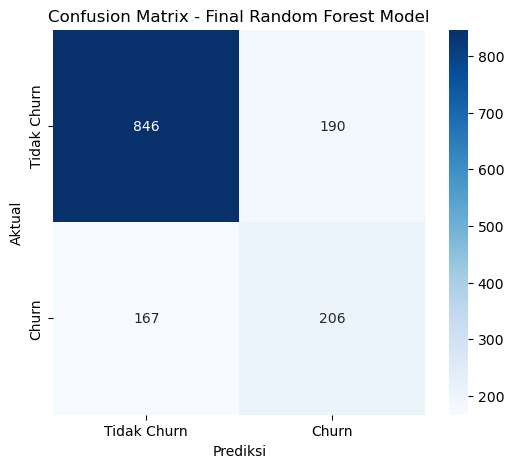

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Buat Confusion Matrix dari Model RF Terbaik
cm = confusion_matrix(y_test, y_pred_test_rf)

# 2. Plotting
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Tidak Churn', 'Churn'],
            yticklabels=['Tidak Churn', 'Churn'])
plt.title('Confusion Matrix - Final Random Forest Model')
plt.ylabel('Aktual')
plt.xlabel('Prediksi')
plt.show()

1. Evaluasi Decision Tree (DT): "Terlalu Konservatif"
- Keberhasilan Mengatasi Overfitting: Proses tuning berhasil secara drastis menghilangkan overfitting yang sebelumnya terjadi. Skor Training turun dari 100% menjadi 87%. Hal ini dikarenakan parameter max_depth terpilih adalah 10. Pembatasan kedalaman pohon ini mencegah model menghapal data latih terlalu detail.

- Penurunan Performa pada Data Uji (Test Set): Meskipun overfitting hilang, model ini justru menjadi underfitting (kurang cerdas) saat menghadapi data asli (Test Set).

    - Recall Kelas Churn (1) hanya 0.43: Artinya, model hanya mampu mendeteksi 43% dari total pelanggan yang sebenarnya churn. Sisanya (57%) gagal dideteksi.

    - F1-Score (0.47): Angka ini tergolong rendah, menunjukkan bahwa Decision Tree tunggal kesulitan menangkap pola kompleks pada data pelanggan jika pohonnya dipangkas terlalu pendek.

2. Evaluasi Random Forest (RF): "Model Terbaik & Paling Stabil"
- Stabilitas Training: Meskipun skor Training masih menunjukkan angka 99%, hal ini wajar bagi algoritma Random Forest yang menggunakan 200 pohon (n_estimators: 200) pada data SMOTE. Namun, yang paling penting adalah performanya pada data Test.

- Peningkatan Kemampuan Deteksi (Recall): Dibandingkan Decision Tree, Random Forest jauh lebih unggul dalam mengenali pelanggan yang berpotensi pergi.

    - Recall Kelas Churn (1) mencapai 0.55: Model ini mampu menangkap 55% pelanggan yang churn. Ini adalah peningkatan signifikan dibanding Decision Tree.

    - Keseimbangan Precision (0.52): Model ini cukup seimbang; dari semua tebakan "Churn" yang dilontarkan model, 52% di antaranya benar.

- Parameter Optimal: Terpilihnya max_depth: 20 menunjukkan bahwa model membutuhkan kedalaman yang cukup kompleks untuk membedakan pola pelanggan setia dan pelanggan churn, namun tetap terkendali berkat mekanisme voting dari 200 pohon.

Berdasarkan perbandingan di atas, penelitian ini menetapkan Random Forest sebagai model terbaik. Alasannya:

1. F1-Score Tertinggi (0.54): Menunjukkan keseimbangan terbaik antara ketepatan prediksi dan kemampuan cakupan deteksi.

2. Recall Lebih Baik (0.55): Dalam kasus Churn Prediction, menangkap sebanyak mungkin pelanggan yang akan pergi (Recall tinggi) seringkali lebih prioritas daripada akurasi total, agar perusahaan dapat melakukan mitigasi lebih awal. Random Forest terbukti lebih peka dibanding Decision Tree.

| Metrik Evaluasi (Kelas Churn/1) | Decision Tree (Tuned) | Random Forest (Tuned) | Keterangan |
| :--- | :--- | :--- | :--- |
| **Accuracy Global** | 74% | **75%** | RF sedikit lebih akurat secara keseluruhan. |
| **Precision** | 0.51 | **0.52** | Kemampuan tebakan benar relatif setara. |
| **Recall (Sensitivitas)** | 0.43 | **0.55** | **RF jauh lebih peka** mendeteksi Churn. |
| **F1-Score** | 0.47 | **0.54** | **RF adalah Model Terbaik** (Keseimbangan optimal). |